Epoch 1: Loss=0.712, Train=0.514, Val=0.609
Epoch 2: Loss=0.629, Train=0.656, Val=0.696
Epoch 3: Loss=0.599, Train=0.740, Val=0.732
Epoch 4: Loss=0.607, Train=0.763, Val=0.739
Epoch 5: Loss=0.541, Train=0.782, Val=0.754
Epoch 6: Loss=0.587, Train=0.808, Val=0.746
Epoch 7: Loss=0.505, Train=0.805, Val=0.746
Epoch 8: Loss=0.466, Train=0.807, Val=0.754
Epoch 9: Loss=0.539, Train=0.807, Val=0.754
Epoch 10: Loss=0.446, Train=0.807, Val=0.768
Epoch 11: Loss=0.443, Train=0.813, Val=0.746
Epoch 12: Loss=0.481, Train=0.816, Val=0.746
Epoch 13: Loss=0.426, Train=0.813, Val=0.754
Epoch 14: Loss=0.435, Train=0.816, Val=0.754
Epoch 15: Loss=0.429, Train=0.821, Val=0.754
Epoch 16: Loss=0.393, Train=0.819, Val=0.761
Epoch 17: Loss=0.400, Train=0.816, Val=0.761
Epoch 18: Loss=0.391, Train=0.818, Val=0.761
Epoch 19: Loss=0.414, Train=0.819, Val=0.754
Epoch 20: Loss=0.389, Train=0.822, Val=0.754


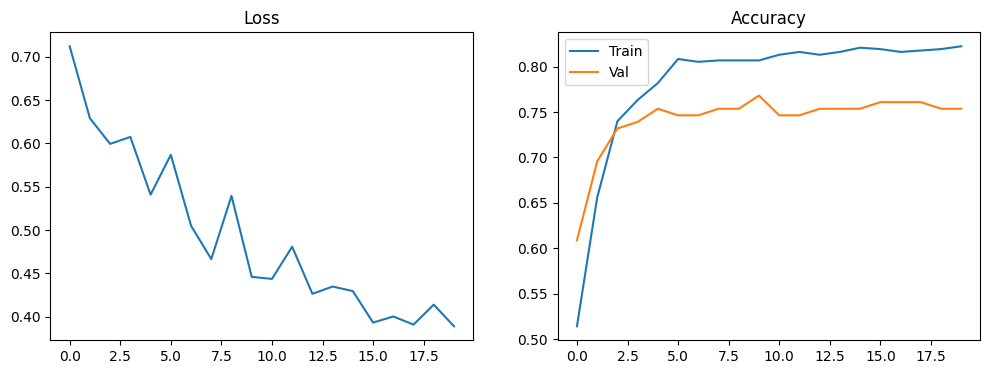

Test Accuracy: 0.8623

Confusion Matrix:
[[51 11]
 [ 8 68]]


In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset

df = pd.read_csv('cleanned.csv')

cat_cols = ['sex', 'cp', 'restecg']
bool_cols = ['fbs', 'exang']

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

for col in bool_cols:
    df[col] = df[col].map({'True':1,'False':0, True:1, False:0}).astype(int)

df['label'] = (df['num'] > 0).astype(int)

features = ['age','sex','cp','trestbps','chol','fbs','restecg','thalch','exang','oldpeak']
X = df[features].values.astype(np.float32)
y = df['label'].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

def make_loader(X, y, bs=64, shuffle=False):
    return DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y)), batch_size=bs, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val, y_val)
test_loader  = make_loader(X_test, y_test)

model = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train(model, train_loader, val_loader, epochs):
    losses, train_accs, val_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / len(train_loader.dataset)

        model.eval()
        correct = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                correct += (out.argmax(1) == y).sum().item()

        val_acc = correct / len(val_loader.dataset)

        losses.append(train_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Loss={train_loss:.3f}, Train={train_acc:.3f}, Val={val_acc:.3f}")

    return losses, train_accs, val_accs

losses, train_accs, val_accs = train(model, train_loader, val_loader, epochs=20)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(losses)
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Val")
plt.legend()
plt.title("Accuracy")

plt.show()

model.eval()
correct = 0

all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        out = model(X)
        preds = out.argmax(1)

        correct += (preds == y).sum().item()
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

test_acc = correct / len(test_loader.dataset)
print("Test Accuracy:", round(test_acc, 4))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(torch.cat(all_labels), torch.cat(all_preds))

print("\nConfusion Matrix:")
print(cm)